<a href="https://colab.research.google.com/github/shreyareddy306-gif/Extreme-Weather-Analysis/blob/main/weather_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd

In [2]:
db_path = "/content/Weather.db"
conn = sqlite3.connect(db_path)

In [3]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,stations
1,sqlite_sequence
2,daily_weather
3,thresholds


In [4]:
df = pd.read_sql("SELECT * FROM daily_weather;", conn)

In [5]:
head = df.head()
desc = df.describe(include='all')

In [6]:
(head,desc)

(   weather_id  station_id        date  tmax_f  tmin_f  wspd_mph  \
 0           1           1  2023-07-01    95.2    75.1      12.0   
 1           2           1  2023-07-02    88.5    70.3       8.5   
 2           3           1  2023-07-03    92.0    71.0      21.3   
 3           4           1  2023-07-04    85.6    65.2      15.8   
 4           5           1  2023-07-05    97.1    77.0      10.2   
 
    precipitation_in  
 0              0.00  
 1              0.10  
 2              0.00  
 3              0.00  
 4              0.05  ,
         weather_id  station_id        date      tmax_f      tmin_f  \
 count    370.00000       370.0         370  370.000000  370.000000   
 unique         NaN         NaN         365         NaN         NaN   
 top            NaN         NaN  2023-07-01         NaN         NaN   
 freq           NaN         NaN           2         NaN         NaN   
 mean     185.50000         1.0         NaN   19.963243   18.263784   
 std      106.95404      

CLEAN STEP BY STEP


In [7]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [8]:
import numpy as np


masking negative values of windspeed and precipitation

In [9]:
df['wspd_mph'] = df['wspd_mph'].mask(df['wspd_mph'] < 0)
df['precipitation_in'] = df['precipitation_in'].mask(df['precipitation_in'] < 0)

now lets handle unrealistic temperatures

In [10]:
df['tmax_f'] = df['tmax_f'].mask((df['tmax_f'] < -50) | (df['tmax_f'] > 130))
df['tmin_f'] = df['tmin_f'].mask((df['tmin_f'] < -50) | (df['tmin_f'] > 130))


check the values again

In [11]:
print(df.describe())

       weather_id  station_id                           date      tmax_f  \
count   370.00000       370.0                            370  335.000000   
mean    185.50000         1.0  2023-07-02 00:19:27.567567872   28.478806   
min       1.00000         1.0            2023-01-01 00:00:00  -50.000000   
25%      93.25000         1.0            2023-04-03 06:00:00   -9.000000   
50%     185.50000         1.0            2023-07-02 12:00:00   31.000000   
75%     277.75000         1.0            2023-09-29 18:00:00   69.000000   
max     370.00000         1.0            2023-12-31 00:00:00  109.000000   
std     106.95404         0.0                            NaN   46.165345   

           tmin_f    wspd_mph  precipitation_in  
count  329.000000  207.000000        202.000000  
mean    28.858967   21.511111          0.471535  
min    -50.000000    0.000000          0.000000  
25%    -12.000000   13.000000          0.212500  
50%     29.000000   21.000000          0.450000  
75%     68.0000

tmax_f and t_min both have same min whihc is -50 which is sus, so lets see when those values are popping up. lets dig deep.

In [12]:
df[(df['tmax_f'] == -50) | (df['tmin_f'] == -50)]

,weather_id,station_id,date,tmax_f,tmin_f,wspd_mph,precipitation_in
120,121,1,2023-04-26,36.0,-50.0,NaN,0.75
145,146,1,2023-05-21,-50.0,NaN,NaN,0.90
260,261,1,2023-09-13,93.0,-50.0,NaN,0.65
284,285,1,2023-10-07,-50.0,-10.0,NaN,NaN


Oh, now we see these seems like a placeholder for bad data or missing data. lets fix this

In [13]:
df['tmax_f'] = df['tmax_f'].replace(-50, np.nan)
df['tmin_f'] = df['tmin_f'].replace(-50, np.nan)

In [15]:
df['tmax_f'] = df['tmax_f'].fillna(df['tmax_f'].mean())
df['tmin_f'] = df['tmin_f'].fillna(df['tmin_f'].mean())

In [14]:
print(df.describe())

       weather_id  station_id                           date     tmax_f  \
count   370.00000       370.0                            370  333.00000   
mean    185.50000         1.0  2023-07-02 00:19:27.567567872   28.95015   
min       1.00000         1.0            2023-01-01 00:00:00  -49.00000   
25%      93.25000         1.0            2023-04-03 06:00:00   -8.00000   
50%     185.50000         1.0            2023-07-02 12:00:00   32.00000   
75%     277.75000         1.0            2023-09-29 18:00:00   69.00000   
max     370.00000         1.0            2023-12-31 00:00:00  109.00000   
std     106.95404         0.0                            NaN   45.89938   

           tmin_f    wspd_mph  precipitation_in  
count  327.000000  207.000000        202.000000  
mean    29.341284   21.511111          0.471535  
min    -49.000000    0.000000          0.000000  
25%    -10.000000   13.000000          0.212500  
50%     30.000000   21.000000          0.450000  
75%     68.500000   32.0

In [16]:
df[(df['tmax_f'] == -49) | (df['tmin_f'] == -49)]

,weather_id,station_id,date,tmax_f,tmin_f,wspd_mph,precipitation_in
90,91,1,2023-03-27,-49.00000,92.000000,NaN,0.9
135,136,1,2023-05-11,-45.00000,-49.000000,39.0,0.5
166,167,1,2023-06-11,-49.00000,89.000000,15.0,0.4
181,182,1,2023-06-26,-49.00000,29.341284,14.0,NaN
230,231,1,2023-08-14,28.95015,-49.000000,NaN,0.2
369,370,1,2023-12-31,-18.00000,-49.000000,34.0,0.2


In [17]:
print(sorted(df['tmax_f'].unique())[:10])
print(sorted(df['tmin_f'].unique())[:10])

[np.float64(-49.0), np.float64(-48.0), np.float64(-47.0), np.float64(-46.0), np.float64(-45.0), np.float64(-41.0), np.float64(-40.0), np.float64(-39.0), np.float64(-38.0), np.float64(-37.0)]
[np.float64(-49.0), np.float64(-48.0), np.float64(-47.0), np.float64(-46.0), np.float64(-44.0), np.float64(-42.0), np.float64(-40.0), np.float64(-39.0), np.float64(-38.0), np.float64(-37.0)]


AS we see that these values are not realistic, but let assume they are and then practise how to do next steps, logically.

lest just define valid ranges of tempseratures.

In [18]:
df['tmax_f'] = df['tmax_f'].mask((df['tmax_f'] < -30) | (df['tmax_f'] > 130))
df['tmin_f'] = df['tmin_f'].mask((df['tmin_f'] < -50) | (df['tmin_f'] > 100))

logical rule that max must be >= min

In [19]:
df.loc[df['tmax_f'] < df['tmin_f'], ['tmax_f', 'tmin_f']] = np.nan

In [20]:
df['wspd_mph'] = df['wspd_mph'].mask(df['wspd_mph'] < 0)

In [21]:
df['precipitation_in'] = df['precipitation_in'].mask(df['precipitation_in'] < 0)

In [22]:
df.describe()

,weather_id,station_id,date,tmax_f,tmin_f,wspd_mph,precipitation_in
count,370.00000,370.0,370,199.000000,232.000000,207.000000,202.000000
mean,185.50000,1.0,2023-07-02 00:19:27.567567872,53.811822,9.184546,21.511111,0.471535
min,1.00000,1.0,2023-01-01 00:00:00,-28.000000,-49.000000,0.000000,0.000000
25%,93.25000,1.0,2023-04-03 06:00:00,28.950150,-21.000000,13.000000,0.212500
50%,185.50000,1.0,2023-07-02 12:00:00,58.000000,8.000000,21.000000,0.450000
75%,277.75000,1.0,2023-09-29 18:00:00,81.500000,29.341284,32.000000,0.700000
max,370.00000,1.0,2023-12-31 00:00:00,109.000000,96.000000,40.000000,0.950000
std,106.95404,0.0,NaN,34.015314,35.700848,11.616013,0.296613


NOW THAT WE ARE DONE WITH CLEANING, LETS START EDA

Visualize Distributions(spot outliners)

In [23]:
import matplotlib.pyplot as plt


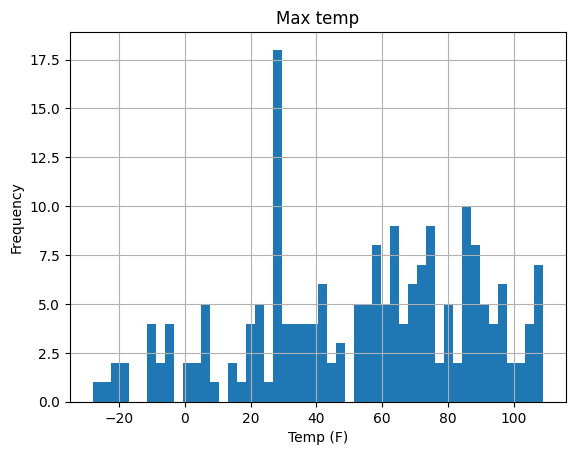

In [ ]:
df['tmax_f'].hist(bins=50)
plt.title("Max temp")
plt.xlabel("Temp (F)")
plt.ylabel("Frequency")
plt.show()

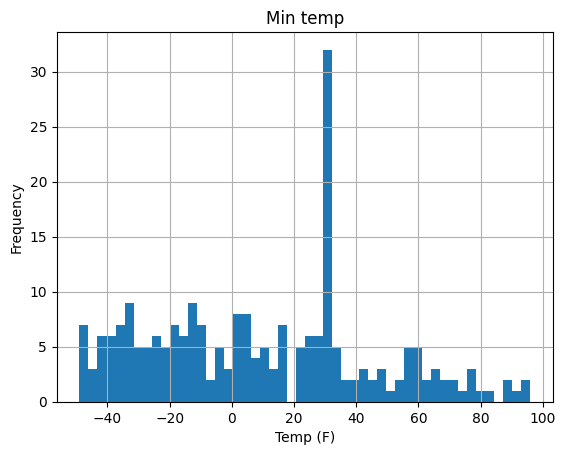

In [24]:
df['tmin_f'].hist(bins=50)
plt.title("Min temp")
plt.xlabel("Temp (F)")
plt.ylabel("Frequency")
plt.show()

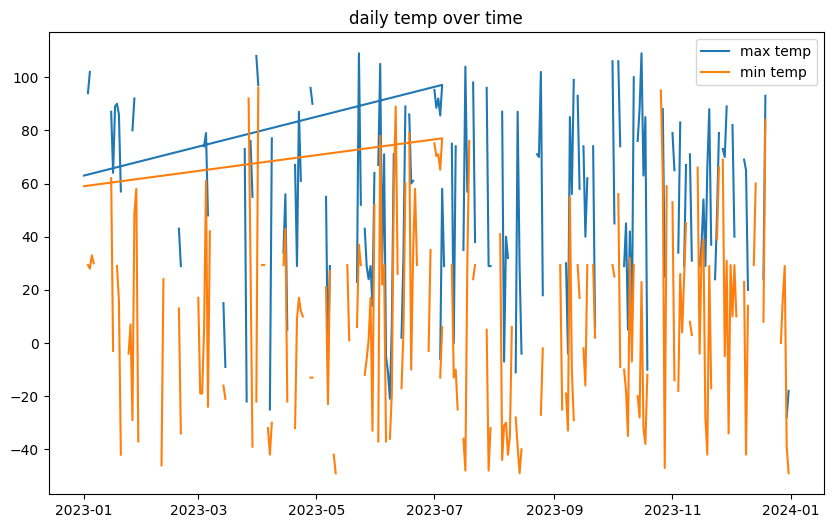

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['tmax_f'], label="max temp")
plt.plot(df['date'], df['tmin_f'], label="min temp")
plt.legend()
plt.title("daily temp over time")
plt.show()

the data still has some noise lets figure it out

In [26]:
df['tmax_f'] = df['tmax_f'].mask((df['tmax_f'] < -30) | (df['tmax_f'] > 110))
df['tmin_f'] = df['tmin_f'].mask((df['tmin_f'] < -40) | (df['tmin_f'] > 95))


lets compute monthly average

In [27]:
df['date'] = pd.to_datetime(df['date'])
monthly_avg = df.groupby(df['date'].dt.to_period("M")).agg({
    'tmax_f': 'mean',
    'tmin_f': 'mean'
}).reset_index()

monthly_avg['date'] = monthly_avg['date'].dt.to_timestamp()

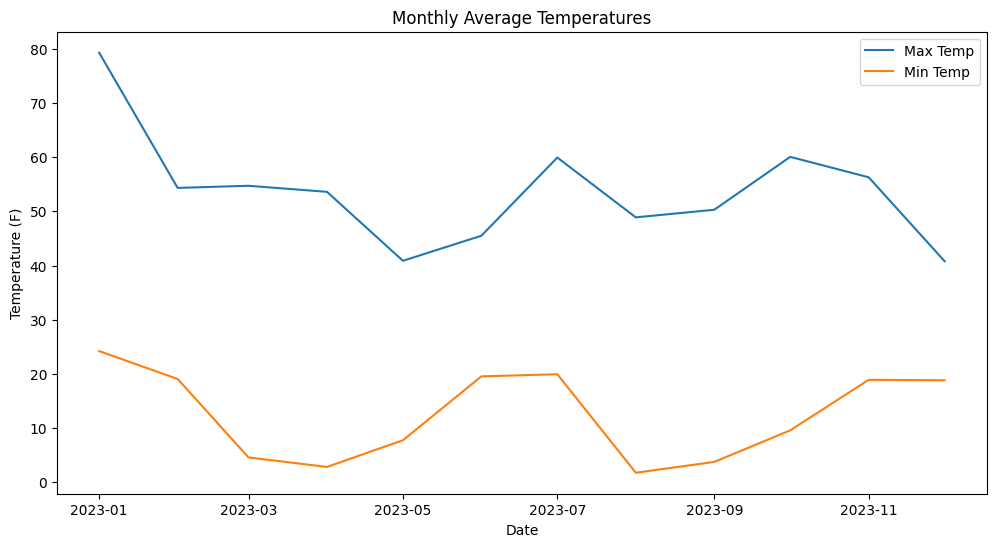

In [28]:
plt.figure(figsize=(12,6))
plt.plot(monthly_avg['date'], monthly_avg['tmax_f'], label='Max Temp')
plt.plot(monthly_avg['date'], monthly_avg['tmin_f'], label='Min Temp')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.title('Monthly Average Temperatures')
plt.legend()
plt.show()

NOW THIS SEEMS PRETTY CLEAN. AND WE CAN CLEARLY SEE HOW THE DATA PROCESSES THROUGHTOUT.

In [29]:
head

,weather_id,station_id,date,tmax_f,tmin_f,wspd_mph,precipitation_in
0,1,1,2023-07-01,95.2,75.1,12.0,0.00
1,2,1,2023-07-02,88.5,70.3,8.5,0.10
2,3,1,2023-07-03,92.0,71.0,21.3,0.00
3,4,1,2023-07-04,85.6,65.2,15.8,0.00
4,5,1,2023-07-05,97.1,77.0,10.2,0.05


In [30]:
query = pd.read_sql("SELECT COUNT(DISTINCT date) as total_days from daily_weather;", conn)
query

,total_days
0,365


In [31]:
query1 = pd.read_sql("SELECT MAX(tmax_f), MIN(tmax_f), MAX(tmin_f), MIN(tmin_f) FROM daily_weather;", conn)

In [32]:
query1

,MAX(tmax_f),MIN(tmax_f),MAX(tmin_f),MIN(tmin_f)
0,109.0,-69.0,120.0,-88.0


In [33]:
query2 = pd.read_sql("SELECT MAX(tmax_f), date FROM daily_weather;", conn)

In [35]:
query2

,MAX(tmax_f),date
0,109.0,2023-01-22


In [34]:
query3 = pd.read_sql("SELECT MIN(tmin_f), date FROM daily_weather;", conn)
query3

,MIN(tmin_f),date
0,-88.0,2023-05-09


In [36]:
query4 = pd.read_sql("SELECT strftime('%Y', date) as year, COUNT(*) AS extreme_heat_days FROM daily_weather WHERE tmax_f >90 GROUP BY year;", conn)
query4

,year,extreme_heat_days
0,2023,28


In [37]:
query5 = pd.read_sql("SELECT strftime('%Y', date) as year, COUNT(*) AS extreme_cold_days FROM daily_weather WHERE tmin_f < 32 GROUP BY year;", conn)
query5

,year,extreme_cold_days
0,2023,211


In [38]:
df.to_csv("daily_weather_clean.csv", index=False)